<a href="https://colab.research.google.com/github/naoya1110/ai_robotics_lab_2026_hands_on/blob/main/Week03_Simple_MLP_Model_with_the_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A simple MLP model with the Iris dataset

## Introduction

In this notebook, we take our first step into deep learning. We will build a simple neural network called a **multi-layer perceptron (MLP)** with PyTorch, and train it with the **Iris dataset**. Iris is a kind of flower. Our goal is to make a model that can tell which of three iris types a flower is.


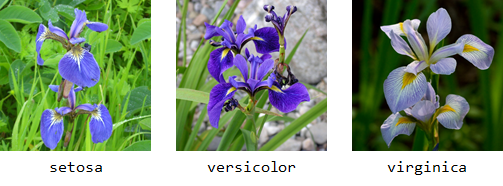

Our model here is not very "deep", so maybe we should not call it "deep learning". But almost all the steps we use here are the same for deeper models.

In this notebook, we will learn:

* The steps of a deep learning program
* How to build and train a simple MLP model
* What a linear layer (fully-connected layer), an activation function, a loss function and an optimizer are


First, let's import some common Python packages.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns     # data visualization package (it uses matplotlib inside)

## Data Preparation

### Iris Dataset

We load the Iris dataset from scikit-learn (`sklearn.datasets`). Scikit-learn is a popular machine learning package in Python. It is not made for deep learning, but it has many useful tools for preparing and checking data, and we will use them often in this course.

*   scikit-learn https://scikit-learn.org/stable/
*   Iris dataset https://en.wikipedia.org/wiki/Iris_flower_data_set

In [28]:
from sklearn.datasets import load_iris

iris_data = load_iris()
print(iris_data)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

The Iris data comes as a Python dictionary. To see it more easily, let's change it into a **Pandas DataFrame**, which looks like a table.

In [29]:
df_iris = pd.DataFrame(iris_data["data"], columns=iris_data["feature_names"])
df_iris["label"] = iris_data["target"]
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


As you can see above, the dataset has 150 samples (150 flowers). Each sample has 4 **features** (sepal length, sepal width, petal length, petal width) and one **label** (the iris type).

If you want to see only the n-th sample, you can do this.

In [30]:
n = 50
df_iris.iloc[n]

,50
sepal length (cm),7.0
sepal width (cm),3.2
petal length (cm),4.7
petal width (cm),1.4
label,1.0


If you do not know the words 'sepal' and 'petal', please look at the picture below.

https://www.math.umd.edu/~petersd/666/html/iris_pca.html

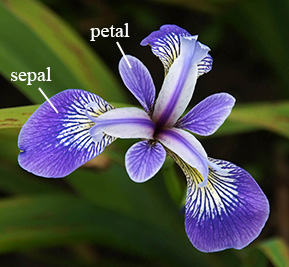

The label is a number, and each number means one iris type, as shown in the table below.

|  label  |  name of iris  |
| :----: | :----: |
|  0  |  setosa  |
|  1  |  versicolor |
| 2| virginica|


`sns.pairplot()` draws many graphs at once. It is useful to see how the features and the labels are related.

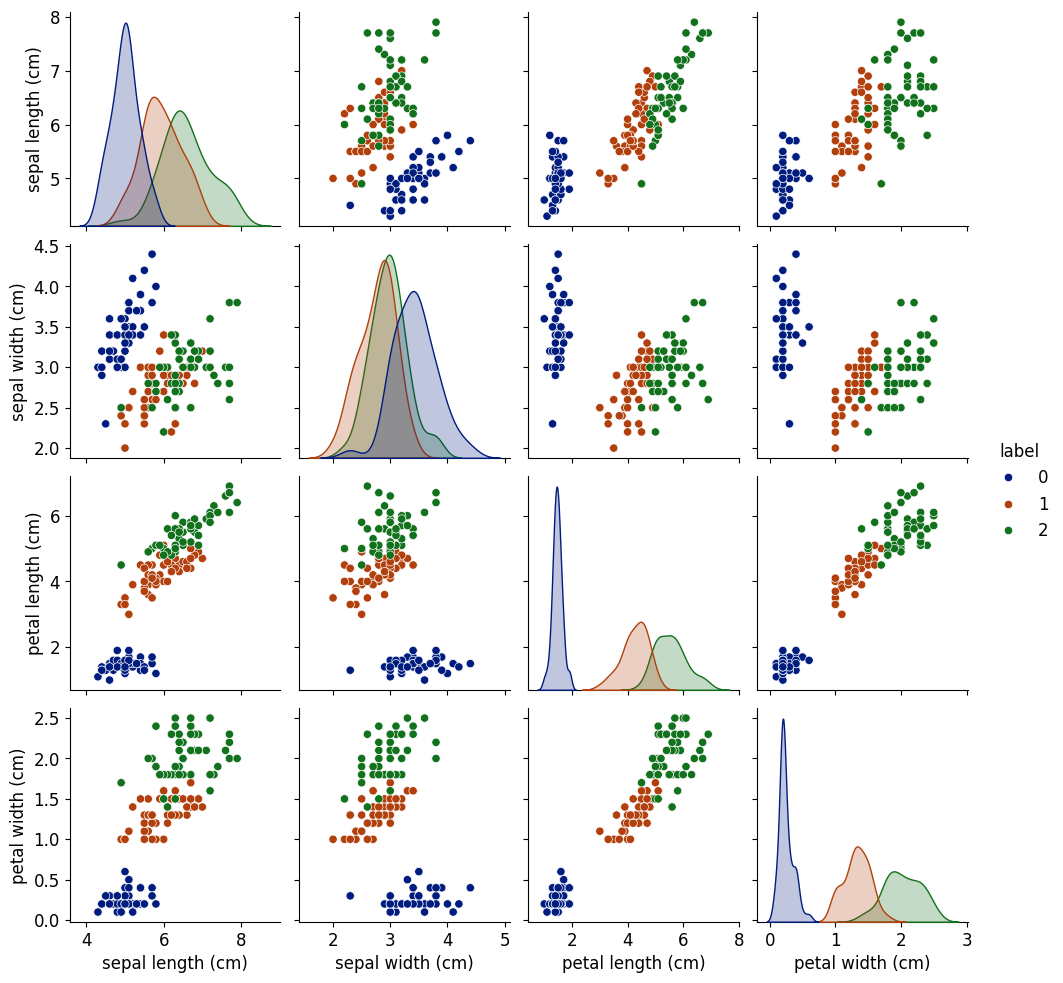

In [56]:
sns.pairplot(df_iris, hue="label", palette="dark")

Our goal is to make an MLP model that tells the iris type from the 4 features: sepal length, sepal width, petal length and petal width. So the 4 features are the input data `x`, and the label number is the output data `y`.

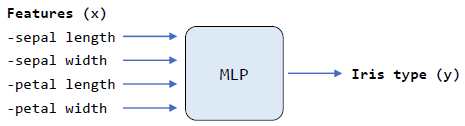

Before we give this data to a PyTorch model, we have to prepare it. This is called **preprocessing**.

### torch.tensor

First, we change the input `x` and the output `y` into tensors (`torch.tensor`), because PyTorch works with tensors. The data type (`dtype`) of `x` must be `torch.float32` (a decimal number), and `y` must be `torch.int64` (a whole number), because `y` is a label number.

In [32]:
import torch

x = torch.tensor(iris_data["data"], dtype=torch.float32)
y = torch.tensor(iris_data["target"], dtype=torch.int64)

### TensorDataset

Next, we put `x` and `y` together into one `TensorDataset` object named `xy_dataset`. It keeps each input with its correct answer.

In [33]:
from torch.utils.data import TensorDataset

xy_dataset = TensorDataset(x, y)
len(xy_dataset)

150

By using an index number, we can see the input and the output of one sample.

In [34]:
xy_dataset[50]

(tensor([7.0000, 3.2000, 4.7000, 1.4000]), tensor(1))

### train test split




Now `xy_dataset` is ready. But we should not use all of it for training.

After training, we want to know how good the model is. For this test, we must use data that the model has never seen during training. If we test with the training data, we cannot know whether the model really learned, or only memorized the answers.

So we split `xy_dataset` into training data (`xy_train`) and test data (`xy_test`).

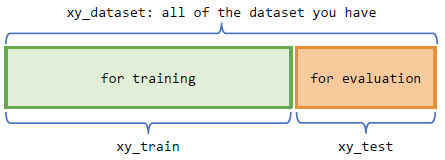

In [35]:
from torch.utils.data import random_split

train_size = 100   # use 100 samples for training
test_size = len(xy_dataset) - train_size     # use the other 50 samples for testing

# split xy_dataset randomly into xy_train and xy_test
xy_train, xy_test = random_split(xy_dataset, [train_size, test_size])

# how many samples are in each?
print("xy_train", len(xy_train))
print("xy_test", len(xy_test))

xy_train 100
xy_test 50


### Data Loader

To give the data to the model, we make `DataLoader` objects named `train_loader` and `test_loader`.

We set `batch_size` to 5. This means the model gets 5 pairs of input and output at a time. Such a small group of data is called a **mini-batch**. The Iris dataset is small, so we could give all the data at once. But in real deep learning the dataset is very large and does not fit in the memory, so we almost always use mini-batches.

We can also **shuffle** the data, which means we change the order of the data. This is usually good for training.

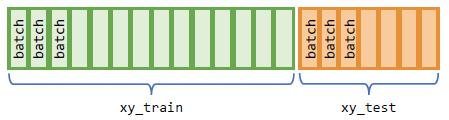

In [36]:
from torch.utils.data import DataLoader

train_loader = DataLoader(xy_train, batch_size=5, shuffle=True)
test_loader = DataLoader(xy_test, batch_size=5, shuffle=False)

If we use the `DataLoader` in a `for` loop, we get the input and the output data, one mini-batch at a time.

In [37]:
for x_batch, y_batch in train_loader:
    print(x_batch)
    print(y_batch)
    break

tensor([[5.6000, 2.9000, 3.6000, 1.3000],
        [5.5000, 3.5000, 1.3000, 0.2000],
        [5.0000, 3.4000, 1.6000, 0.4000],
        [5.3000, 3.7000, 1.5000, 0.2000],
        [6.7000, 3.1000, 5.6000, 2.4000]])
tensor([1, 0, 0, 0, 2])


That's it for data preparation!

## Building a Model

### Model Architecture

The next step is to build the neural network model.

Our MLP has three layers: an **input layer**, a **hidden layer** and an **output layer**. The input layer has 4 neurons, one for each feature. The hidden layer can have any number of neurons (we will use 10). The output layer has 3 neurons, one for each iris type. The neuron with the largest value shows which iris type the model thinks it is.

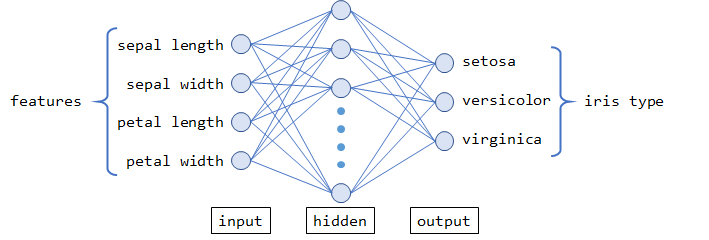

In PyTorch, we usually make a model as a Python class, so let's do it in that way.

In [38]:
import torch.nn as nn

# make our own class named "Model"
class Model(nn.Module):

    # Constructor: this runs when we make a model
    def __init__(self):                 # do not change
        super(Model, self).__init__()   # do not change

        # the layers of the network, in order
        self.classifier = nn.Sequential(
            nn.Linear(in_features=4, out_features=10),
            nn.ReLU(),
            nn.Linear(in_features=10, out_features=3)
        )

    # forward(): this runs when we give data to the model
    def forward(self, x):        # do not change
        x = self.classifier(x)
        return x

model = Model()    # make a model
print(model)

Model(
  (classifier): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=3, bias=True)
  )
)


Our model is made of **Linear layers** and an activation function called **ReLU**. But what do they do?

### Linear Layers

A Linear Layer is also called a Fully Connected Layer or a Dense Layer. It is the most important part of a neural network.

Let's look at an example. 'layer0' has three neurons ($x_0$, $x_1$, $x_2$), and the next layer, 'layer1', has two neurons ($y_0$, $y_1$). In a Linear Layer, **every** neuron in 'layer1' is connected to **every** neuron in 'layer0'. Each connection has its own **weight** ($w_{00}$, $w_{01}$, $w_{02}$, $w_{10}$, $w_{11}$, $w_{12}$), and each neuron in 'layer1' has its own **bias** ($b_0$, $b_1$).

A weight shows how strong a connection is. The model learns these weights and biases, and in this way it learns the patterns in the data.

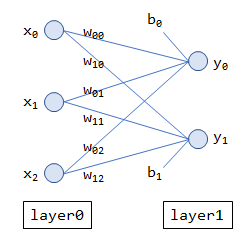

We calculate $y_0$ and $y_1$ from the neurons of the previous layer, their weights and their biases, like this. All the weights and biases are **trainable parameters**: the model changes them during training.


$y_0 = w_{00}x_0 + w_{01}x_1 + w_{02}x_2 + b_0$

$y_1 = w_{10}x_0 + w_{11}x_1 + w_{12}x_2 + b_1$

Let's do this calculation in code.

In [39]:
X = torch.tensor([0.2, 0.7, -0.5])     # [x0, x1, x2] neurons in layer0

W0 = torch.tensor([1.0, 0.1, 0.5])     # [w00, w01, w02] weights for y0
W1 = torch.tensor([-0.6, 0.8, 0.2])    # [w10, w11, w12] weights for y1
b0 = 0.5                               # bias for y0
b1 = -0.7                              # bias for y1

y0 = torch.sum(W0*X)+b0
y1 = torch.sum(W1*X)+b1

print("y0 =", y0)
print("y1 =", y1)

y0 = tensor(0.5200)
y1 = tensor(-0.3600)


### ReLU - Activation Function

After a linear layer, we usually use an **activation function**. Here we use **ReLU** (Rectified Linear Unit) on the output of 'layer1'. ReLU is very simple: if the input is negative, the output is 0; if the input is positive, the output stays the same.

A linear layer can only draw straight lines. With an activation function, the model can learn curved and more difficult patterns.

In [40]:
def relu(x):
    return max(torch.tensor(0.0), x)

y0 = relu(y0)
y1 = relu(y1)

print("y0 =", y0)
print("y1 =", y1)

y0 = tensor(0.5200)
y1 = tensor(0.)


## Training

### Loss Function

During training, we need a number that tells us how far the model's predictions are from the correct answers. We get this number from a **loss function**. A large loss means many mistakes, and a small loss means good predictions.

For classification, we usually use the **cross-entropy loss** (`nn.CrossEntropyLoss()`).


* `nn.CrossEntropyLoss()` https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

In [41]:
loss_func = nn.CrossEntropyLoss()

The page above shows the equation of the cross-entropy loss below. Here $p_i$ is the model's output for the $i$-th type of iris, and $p_y$ is the model's output for the correct type.

If the model gives a large value to the correct type, the loss becomes small.

$\displaystyle \mathrm{loss} =  -\ln\left(\exp(p_y)/\sum_{i=0}^{n-1} \exp(p_i)\right) = -p_y + \ln\left(\sum_{i=0}^{n-1} \exp(p_i)\right)$

Let's check this equation in code. The result should be the same as `nn.CrossEntropyLoss()`.

In [42]:
p = torch.tensor([0.1, 3, -2])    # model outputs for the 3 types [setosa, versicolor, virginica]
y = torch.tensor(1)               # correct answer: label 1 [versicolor]

loss = -p[y] + torch.log(torch.sum(torch.exp(p)))
loss

tensor(0.0599)

In [43]:
p = torch.tensor([[0.1, 3, -2]])
y = torch.tensor([1])

loss_func(p, y)

tensor(0.0599)

### Optimizer

During training, the model parameters (the weights and the biases) are changed little by little to make the loss smaller. The method that changes them is called an **optimizer**. Here we use **Adam**, but there are many other optimizers. The parameter `lr` is the **learning rate**. It decides how much the parameters change at each step.

* `optim.Adam()` https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam

In [44]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1E-3)

### Training Loop

Now we are ready to train the model. The code is a little long, but most of it is the same for other datasets and other models. Once you get used to it, it becomes easy.

One **epoch** means the model looks at all the training data one time. In each epoch, we do these steps for every mini-batch:

1. **Predict**: the model calculates its outputs for the inputs.
2. **Measure the loss**: we compare the outputs with the correct answers.
3. **Calculate the gradients**: `loss.backward()` finds which way to change the parameters.
4. **Update the parameters**: `optimizer.step()` changes the weights and the biases.

After the training part of each epoch, we also check the model with the test data. Here we do **not** update the parameters; we only measure the loss and the **accuracy** (how many predictions are correct).

The main parts of the training loop are shown below.





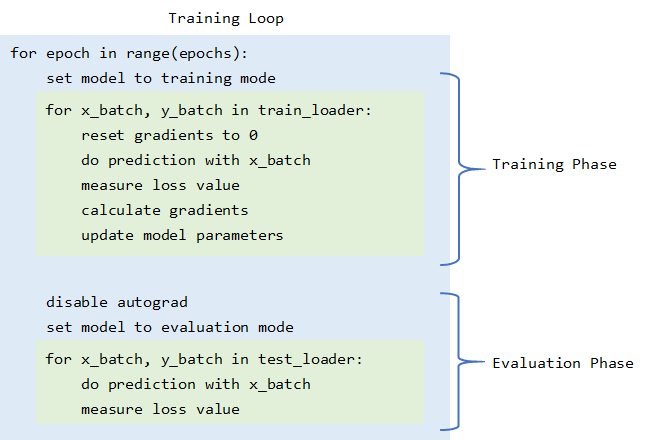

In [45]:
model = Model()                                        # make a new model
loss_func = nn.CrossEntropyLoss()                      # set loss function
optimizer = optim.Adam(model.parameters(), lr=1E-3)    # set optimizer


epochs = 50  # how many times we repeat the training

# empty lists for saving the results of each epoch
train_loss_list = []
train_accuracy_list = []
test_loss_list = []
test_accuracy_list = []

# training loop
for epoch in range(epochs):

    # reset the numbers for this epoch
    train_correct_count = 0
    train_accuracy = 0
    train_loss = 0
    test_correct_count = 0
    test_accuracy = 0
    test_loss = 0

    #--- Training Phase ---#
    model.train()    # set model to training mode

    for x_batch, y_batch in train_loader:      # take one mini-batch from train_loader
        optimizer.zero_grad()                  # reset the gradients to 0
        p_batch = model(x_batch)               # make a prediction
        loss = loss_func(p_batch, y_batch)     # measure loss
        loss.backward()                        # calculate the gradients
        optimizer.step()                       # update model parameters

        train_loss += loss.item()                                # add up the loss
        p_batch_label = torch.argmax(p_batch, dim=1)             # the largest output = the predicted label
        train_correct_count += (p_batch_label == y_batch).sum()  # count the correct predictions
    #----------------------#

    #--- Evaluation Phase ---#
    with torch.no_grad():   # no gradients here, so it uses less memory
        model.eval()        # set model to evaluation mode

        for x_batch, y_batch in test_loader:      # take one mini-batch from test_loader
            p_batch = model(x_batch)              # make a prediction
            loss = loss_func(p_batch, y_batch)    # measure loss

            test_loss += loss.item()                                # add up the loss
            p_batch_label = torch.argmax(p_batch, dim=1)            # the largest output = the predicted label
            test_correct_count += (p_batch_label == y_batch).sum()  # count the correct predictions
    #------------------------#

    train_accuracy = train_correct_count/len(xy_train)   # accuracy for the training data
    test_accuracy = test_correct_count/len(xy_test)      # accuracy for the test data
    train_loss = train_loss/len(train_loader)            # average loss for the training data
    test_loss = test_loss/len(test_loader)               # average loss for the test data

    # print and save the results
    print(f"Epoch {epoch+1} Train: Accuracy={train_accuracy:.3f} Loss={train_loss:.3f}, Test: Accuracy={test_accuracy:.3f} Loss={test_loss:.3f}")
    train_accuracy_list.append(train_accuracy)
    train_loss_list.append(train_loss)
    test_accuracy_list.append(test_accuracy)
    test_loss_list.append(test_loss)

Epoch 1 Train: Accuracy=0.480 Loss=1.219, Test: Accuracy=0.400 Loss=1.097
Epoch 2 Train: Accuracy=0.390 Loss=1.144, Test: Accuracy=0.400 Loss=1.064
Epoch 3 Train: Accuracy=0.340 Loss=1.102, Test: Accuracy=0.380 Loss=1.026
Epoch 4 Train: Accuracy=0.340 Loss=1.057, Test: Accuracy=0.400 Loss=0.997
Epoch 5 Train: Accuracy=0.350 Loss=1.020, Test: Accuracy=0.400 Loss=0.966
Epoch 6 Train: Accuracy=0.350 Loss=0.986, Test: Accuracy=0.400 Loss=0.937
Epoch 7 Train: Accuracy=0.340 Loss=0.951, Test: Accuracy=0.400 Loss=0.905
Epoch 8 Train: Accuracy=0.350 Loss=0.917, Test: Accuracy=0.400 Loss=0.876
Epoch 9 Train: Accuracy=0.470 Loss=0.885, Test: Accuracy=0.640 Loss=0.848
Epoch 10 Train: Accuracy=0.700 Loss=0.849, Test: Accuracy=0.700 Loss=0.817
Epoch 11 Train: Accuracy=0.700 Loss=0.817, Test: Accuracy=0.700 Loss=0.786
Epoch 12 Train: Accuracy=0.740 Loss=0.784, Test: Accuracy=0.700 Loss=0.757
Epoch 13 Train: Accuracy=0.740 Loss=0.753, Test: Accuracy=0.700 Loss=0.728
Epoch 14 Train: Accuracy=0.710 Los

### Learning Curves

After training, it is always good to check how the training went, and how the accuracy and the loss changed.

Let's draw the accuracy curves for the training data and the test data.

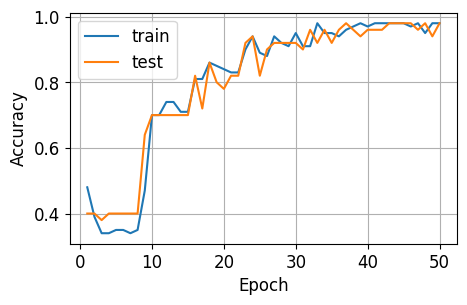

In [46]:
plt.figure(figsize=(5,3))
plt.rcParams["font.size"]=12
plt.plot(np.arange(epochs)+1, train_accuracy_list, label="train")
plt.plot(np.arange(epochs)+1, test_accuracy_list, label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

Let's also draw the loss curves for the training data and the test data.

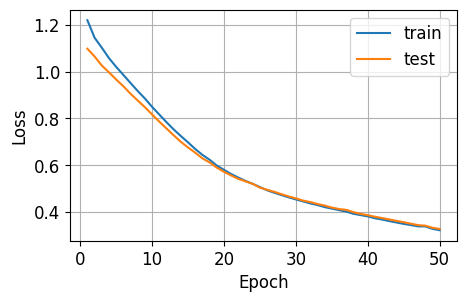

In [47]:
plt.figure(figsize=(5,3))
plt.rcParams["font.size"]=12
plt.plot(np.arange(epochs)+1, train_loss_list, label="train")
plt.plot(np.arange(epochs)+1, test_loss_list, label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

## Evaluation

### Test Accuracy

Let's check the accuracy of the trained model with the test data.

In [48]:
test_correct_count = 0

y_test_all = np.array([])
p_label_all = np.array([])

with torch.no_grad():   # no gradients here, so it uses less memory
    model.eval()        # set model to evaluation mode

    for x_batch, y_batch in test_loader:      # take one mini-batch from test_loader
        p_batch = model(x_batch)              # make a prediction

        p_batch_label = torch.argmax(p_batch, dim=1)            # the largest output = the predicted label
        test_correct_count += (p_batch_label == y_batch).sum()  # count the correct predictions

        y_test_all = np.append(y_test_all, y_batch.numpy())          # save the correct answers
        p_label_all = np.append(p_label_all, p_batch_label.numpy())  # save the predictions

test_accuracy = test_correct_count/len(xy_test)      # accuracy for the test data
print(f"Test Accuracy = {test_accuracy:.3f}")

Test Accuracy = 0.980


### Confusion Matrix

A **confusion matrix** is also useful. It shows the accuracy for each iris type, so we can see which types the model often mixes up.

Text(0.5, 1.0, 'confusion matrix')

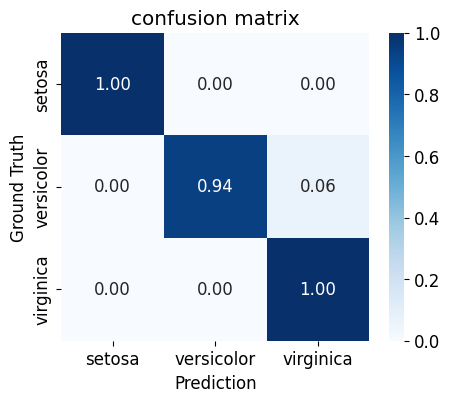

In [49]:
from sklearn.metrics import confusion_matrix

cmx = confusion_matrix(y_test_all, p_label_all)

cmx_pct = np.zeros(cmx.shape)

for i in range(cmx.shape[0]):
    for j in range(cmx.shape[1]):
        cmx_pct[i, j] = cmx[i, j]/cmx[i, :].sum()

plt.figure(figsize=(5,4))
plt.rcParams["font.size"]=12
labels = iris_data["target_names"]

sns.heatmap(cmx_pct, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels, square=True)

plt.ylabel("Ground Truth")
plt.xlabel("Prediction")
plt.title("confusion matrix")

## Prediction with New Data
Now let's say we have new data: the 4 features of a new iris flower, and we do not know its type.

In [50]:
# features of a new, unknown flower
sepal_l = 3.0
sepal_w = 2.0
petal_l = 1.0
petal_w = 0.5

x = [sepal_l, sepal_w, petal_l, petal_w]
x = torch.tensor([x], dtype=torch.float32)
print(x)

tensor([[3.0000, 2.0000, 1.0000, 0.5000]])


We can predict the type of this new flower with the trained model. Note that we use `torch.softmax()` on the model's outputs:

$\displaystyle \mathrm{Softmax}(x_i) = \exp(x_i)/\sum_{j=0}^{N-1}\exp(x_j)$

Softmax changes the outputs into numbers between 0 and 1, and their sum becomes 1. So we can read them as the **probability** of each iris type.

In [51]:
with torch.no_grad():
    pred = model(x)
    print("pred =", pred)

    prob = torch.softmax(pred, dim=1)
    print("prob =", prob)
    print("sum of prob =", prob.sum())

pred = tensor([[ 1.1744, -0.0447, -3.0062]])
prob = tensor([[0.7629, 0.2254, 0.0117]])
sum of prob = tensor(1.)


In [52]:
print("Probability")
print(f"setosa {prob[0, 0].item():.1%}")
print(f"versicolor {prob[0, 1].item():.1%}")
print(f"virginica {prob[0, 2].item():.1%}")

Probability
setosa 76.3%
versicolor 22.5%
virginica 1.2%


## Practice

Let's try to change the MLP model like this:


* The model has two hidden layers.
* The first hidden layer has 10 neurons, followed by a ReLU activation function.
* The second hidden layer has 20 neurons, followed by a ReLU activation function.

After you change the model, train it again!

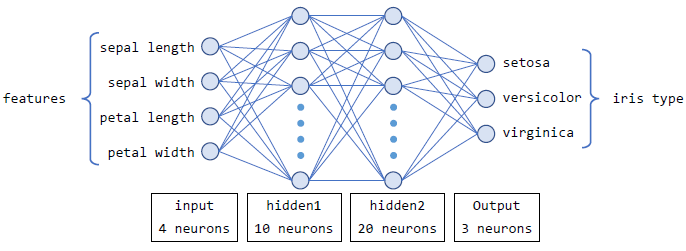

## Conclusion

That's it for this week. We have learned the basics of deep learning. Now you can try to change the values below and see how the results change:

* Batch size in the data loader
* Number of neurons in the hidden layer
* Number of hidden layers
* Learning rate of the optimizer
* Type of optimizer
* Number of epochs
* And more

These values, which we choose by ourselves before training, are called **hyperparameters**.